# Gün 7 — Derinlemesine EDA

**Staj günü:** 7 (09.07.2026)
**Amaç:** Gün 6'daki temel EDA'nın üzerine, wetstock verisini domain açısından
derinlemesine incelemek:
1. Sıcaklık ile kayıp/kazanç ilişkisi
2. Kümülatif kayıp trendleri (hangi tank sürekli kaybediyor?)
3. Tanklar arası karşılaştırma
4. **Manifold çifti analizi** (bir tankta kayıp -> eşleşen tankta kazanç?)
5. Null/eksik veri kümelenmesi (probe arızası paterni)

> Veri: gerçek WSM raporlarının profiline kalibre edilmiş, **anonim ve sentetik** ambar.


In [1]:
import sys
from pathlib import Path
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if ROOT.name != 'eda': ROOT = ROOT / 'eda'
sys.path.insert(0, str(ROOT))
from utils.data_loader import load_all

pd.set_option('display.max_columns', 40)
plt.rcParams['figure.figsize'] = (12, 4)

dfs = load_all()
ue = dfs['ue1t_30min']
tanks = dfs['tanks']
inv = dfs['inventory_30min']
print('ue1t:', ue.shape, '| tanks:', tanks.shape, '| inventory:', inv.shape)

ue1t: (138194, 16) | tanks: (32, 11) | inventory: (138194, 11)


## 1. Sıcaklık — Kayıp/Kazanç ilişkisi

Sıcaklık değişimi hacmi etkiler (ısınınca genleşir, soğuyunca büzülür). Eğer kayıp
sıcaklıkla ilişkiliyse, bu bir **sızıntı değil sıcaklık kaynaklı** farktır. Bunu
scatter + korelasyon ile test ediyoruz.


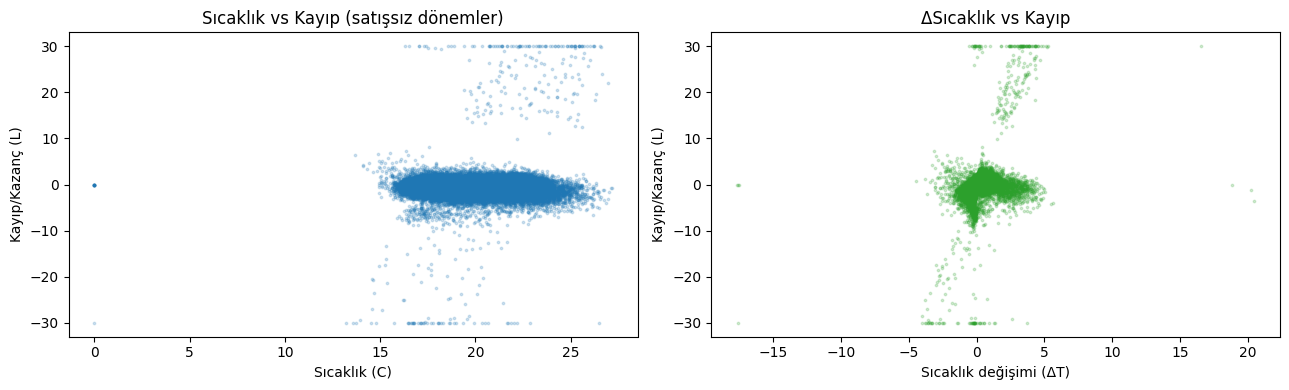

Korelasyon (kayip_kazanc ile):
sicaklik        0.014
dsic            0.087
kayip_kazanc    1.000


In [2]:
# sadece satışsız dönemler: sıcaklık etkisini en temiz burada görürüz
nosale = ue[(ue.pompa_satis == 0) & ue.sicaklik.notna()].copy()
nosale['dsic'] = nosale.groupby(['istasyon_kodu','tank_no'])['sicaklik'].diff()
sub = nosale.dropna(subset=['dsic'])

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].scatter(sub['sicaklik'], sub['kayip_kazanc'].clip(-30,30), s=3, alpha=0.2)
ax[0].set_xlabel('Sıcaklık (C)'); ax[0].set_ylabel('Kayıp/Kazanç (L)')
ax[0].set_title('Sıcaklık vs Kayıp (satışsız dönemler)')
ax[1].scatter(sub['dsic'], sub['kayip_kazanc'].clip(-30,30), s=3, alpha=0.2, color='tab:green')
ax[1].set_xlabel('Sıcaklık değişimi (ΔT)'); ax[1].set_ylabel('Kayıp/Kazanç (L)')
ax[1].set_title('ΔSıcaklık vs Kayıp')
plt.tight_layout(); plt.show()

corr = sub[['sicaklik','dsic','kayip_kazanc']].corr()['kayip_kazanc']
print('Korelasyon (kayip_kazanc ile):')
print(corr.round(3).to_string())

## 2. Kümülatif kayıp trendleri

Kümülatif kayıp eğiminin sürekli aşağı gitmesi = kronik kayıp (olası sızıntı).
Birkaç tankı üst üste çizip karşılaştırıyoruz.


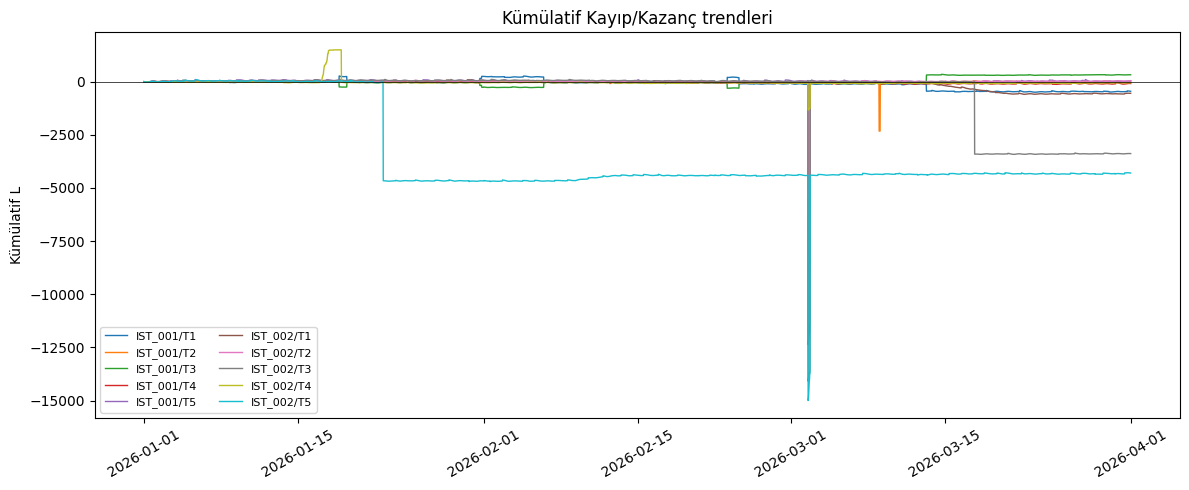

In [3]:
fig, ax = plt.subplots(figsize=(12, 5))
for (st, tk), g in ue.groupby(['istasyon_kodu','tank_no']):
    if st in ('IST_001','IST_002') :
        g = g.sort_values('saat_1')
        ax.plot(g['saat_1'], g['kumulatif_kayip_kazanc'], lw=1, label=f'{st}/T{tk}')
ax.axhline(0, color='k', lw=0.5)
ax.set_title('Kümülatif Kayıp/Kazanç trendleri')
ax.set_ylabel('Kümülatif L'); ax.legend(fontsize=8, ncol=2)
plt.xticks(rotation=30); plt.tight_layout(); plt.show()

## 3. Tanklar arası karşılaştırma

Tank bazında kayıp/kazanç dağılımını box plot ile karşılaştırıyoruz — hangi tank
daha "gürültülü" veya sürekli negatif?


/tmp/ipykernel_530/2834135299.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=keys, showfliers=False)


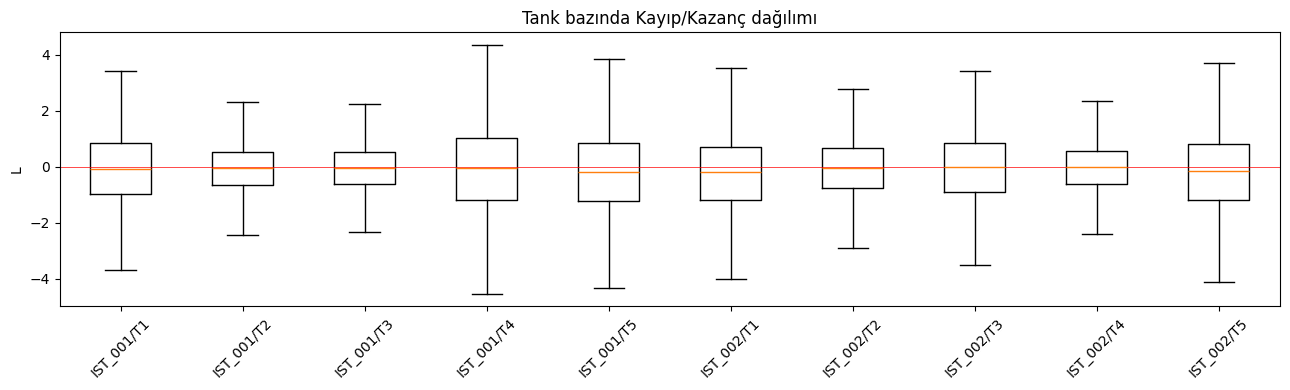

Tank bazında ortalama kayıp/kazanç (ilk 10):
tank_key
IST_001/T1   -0.11
IST_001/T2    0.00
IST_001/T3    0.07
IST_001/T4   -0.02
IST_001/T5    0.01
IST_002/T1   -0.13
IST_002/T2    0.01
IST_002/T3   -0.78
IST_002/T4   -0.01
IST_002/T5   -0.99


In [4]:
ue['tank_key'] = ue['istasyon_kodu'] + '/T' + ue['tank_no'].astype(str)
keys = ue['tank_key'].unique()[:10]
data = [ue[ue.tank_key==k]['kayip_kazanc'].clip(-40,40).values for k in keys]
plt.figure(figsize=(13,4))
plt.boxplot(data, labels=keys, showfliers=False)
plt.axhline(0, color='r', lw=0.5)
plt.title('Tank bazında Kayıp/Kazanç dağılımı'); plt.ylabel('L')
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

print('Tank bazında ortalama kayıp/kazanç (ilk 10):')
print(ue.groupby('tank_key')['kayip_kazanc'].mean().round(2).head(10).to_string())

## 4. Manifold çifti analizi  ⭐

Manifold ile bağlı iki tank arasında check-valve kaçırması olursa: **bir tankta kayıp,
eşleşen tankta aynı anda kazanç** görülür. `tanks` tablosundan manifold gruplarını bulup
çiftin kayıp/kazancını yan yana inceliyoruz. Bu, ileride kural tabanlı tespit motorunun
temeli olacak.


Manifold tank çiftleri:
istasyon_kodu  tank_no  manifold_grup_no
      IST_001        1                 1
      IST_001        3                 1
      IST_004        2                 1
      IST_004        4                 1
      IST_005        1                 1
      IST_005        3                 1
      IST_007        2                 1
      IST_007        4                 1

İnceleniyor: IST_001 manifold grup 1, tanklar [1, 3]


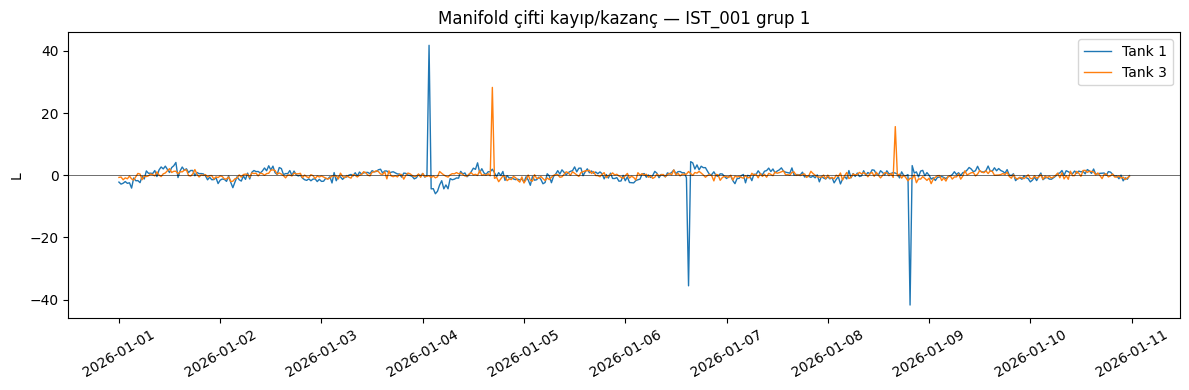

In [5]:
man = tanks[tanks.is_manifold == 1][['istasyon_kodu','tank_no','manifold_grup_no']]
print('Manifold tank çiftleri:')
print(man.to_string(index=False))

# ilk manifold grubunu seç ve iki tankın kayıp/kazancını aynı zaman ekseninde çiz
grp = man.groupby(['istasyon_kodu','manifold_grup_no'])
first_key = list(grp.groups.keys())[0]
st, mg = first_key
pair = man[(man.istasyon_kodu==st) & (man.manifold_grup_no==mg)]['tank_no'].tolist()
print(f'\nİnceleniyor: {st} manifold grup {mg}, tanklar {pair}')

fig, ax = plt.subplots(figsize=(12,4))
for tk in pair[:2]:
    g = ue[(ue.istasyon_kodu==st) & (ue.tank_no==tk)].sort_values('saat_1').head(48*10)
    ax.plot(g['saat_1'], g['kayip_kazanc'], lw=1, label=f'Tank {tk}')
ax.axhline(0, color='k', lw=0.4)
ax.set_title(f'Manifold çifti kayıp/kazanç — {st} grup {mg}')
ax.set_ylabel('L'); ax.legend()
plt.xticks(rotation=30); plt.tight_layout(); plt.show()

## 5. Null / eksik veri kümelenmesi

Null'lar rastgele değil, arıza senaryolarına bağlı. Sıcaklık null'larının hangi
tank/günlerde toplandığını görürsek probe arızası paternini yakalarız.


In [6]:
# sıcaklık null'ları hangi tank/günde?
tmp = ue.copy()
tmp['gun'] = tmp['saat_1'].dt.date
tmp['sic_null'] = tmp['sicaklik'].isna()
pivot = tmp.groupby(['istasyon_kodu','tank_no'])['sic_null'].sum()
print('Sıcaklık NaN sayısı (tank bazında, >0 olanlar):')
print(pivot[pivot>0].to_string())

# envanterdeki su/net null'ları
print('\ninventory_30min null kolonları:')
print(inv.isna().sum()[inv.isna().sum()>0].to_string())

Sıcaklık NaN sayısı (tank bazında, >0 olanlar):
istasyon_kodu  tank_no
IST_002        1          48
               4          48
IST_003        1          48
               3          48
IST_008        2          48

inventory_30min null kolonları:
urun_miktari_net        240
su_seviyesi_cm           48
su_miktari               48
sicaklik                240
merkeze_gelis_tarihi    276


## Gün 7 Özeti

- **Sıcaklık–kayıp ilişkisi** korelasyonla incelendi (sıcaklık kaynaklı fark ayrımı için).
- **Kümülatif kayıp trendleri** çizildi (kronik kayıp / olası sızıntı tespiti).
- **Tanklar arası** dağılım box plot ile karşılaştırıldı.
- **Manifold çifti** analizi yapıldı (bir tankta kayıp / diğerinde kazanç paterni).
- **Null kümelenmesi** incelendi (probe arızası paterni).

**Sonraki adım (Gün 8 / SQL):** bulguları SQL sorgularıyla doğrulama ve feature engineering'e hazırlık.
